In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"

df = pd.read_csv(url)

df.head()

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


In [2]:
df['Date']= pd.to_datetime(df['Date'])
df =df.sort_values('Date')
df.set_index('Date',inplace = True)
df.head()

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


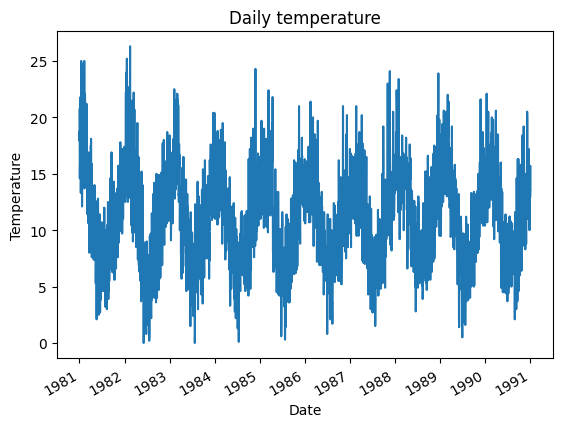

In [3]:
import matplotlib.pyplot as plt
plt.figure()
df['Temp'].plot()
plt.title("Daily temperature")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.show()

In [4]:
df['Lag1']= df['Temp'].shift(1)
df['Lag2']=df['Temp'].shift(2)
df['Lag3']= df['Temp'].shift(3)
df = df.dropna()
df.head()

,Temp,Lag1,Lag2,Lag3
Date,,,,
1981-01-04,14.6,18.8,17.9,20.7
1981-01-05,15.8,14.6,18.8,17.9
1981-01-06,15.8,15.8,14.6,18.8
1981-01-07,15.8,15.8,15.8,14.6
1981-01-08,17.4,15.8,15.8,15.8


In [5]:
train_size = int(len(df)*0.8)
train = df.iloc[:train_size]
test = df.iloc[train_size:]

x_train = train[['Lag1','Lag2','Lag3']]
y_train = train['Temp']

x_test = test[['Lag1','Lag2','Lag3']]
y_test = test['Temp']

In [6]:
from numpy._core.fromnumeric import mean
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

model = LinearRegression()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print("RMSE",rmse)

RMSE 2.322364231071762


In [12]:
#Adding more lag features
df_lag = df.copy()
df_lag['Lag1']= df_lag['Temp'].shift(1)
df_lag['Lag2']= df_lag['Temp'].shift(2)
df_lag['Lag3']= df_lag['Temp'].shift(3)
df_lag['Lag7']= df['Temp'].shift(7)
df_lag['Lag30']=df['Temp'].shift(30)
df_lag = df_lag.dropna()


In [8]:
print(df_lag.columns)

Index(['Temp', 'Lag1', 'Lag2', 'Lag3'], dtype='object')


In [13]:
train_size = int(len(df_lag)*0.8)
train = df_lag.iloc[:train_size]
test = df_lag.iloc[train_size:]

x_train = train[['Lag1','Lag2','Lag3','Lag7','Lag30']]
y_train = train['Temp']

x_test = test[['Lag1','Lag2','Lag3','Lag7','Lag30']]
y_test = test['Temp']

In [14]:
# Re-Training
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

model = LinearRegression()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print("New RMSE",rmse)

New RMSE 2.243344808082526


RMSE improved from 2.32 to 2.243. That's a small improvemnt, helped slightly but not dramatically. Because temperature has strong yearly seasonality,not just weekly /monthly

In [15]:
#Adding date-based features

df_lag['Month'] = df_lag.index.month
df_lag['DayOfYear'] = df_lag.index.dayofyear

In [16]:
#Adding seasonal encoding

import numpy as np
df_lag['Sin_Day'] = np.sin(2*np.pi*df_lag['DayOfYear']/365)
df_lag['Cos_Day'] = np.cos(2*np.pi*df_lag['DayOfYear']/365)

In [17]:
# Re training

train_size = int(len(df_lag) * 0.8)

train = df_lag.iloc[:train_size]
test = df_lag.iloc[train_size:]

features = ['Lag1','Lag2','Lag3','Lag7','Lag30',
            'Sin_Day','Cos_Day']

X_train = train[features]
y_train = train['Temp']

X_test = test[features]
y_test = test['Temp']

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Improved RMSE:", rmse)

Improved RMSE: 2.1576223999697506


In [18]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("Random Forest RMSE:", rmse_rf)


Random Forest RMSE: 2.176651568762346


Linear regression already captures the pattern well. Randomforest can not significantly improve well. Probably due to smooth seasonal nature of the data

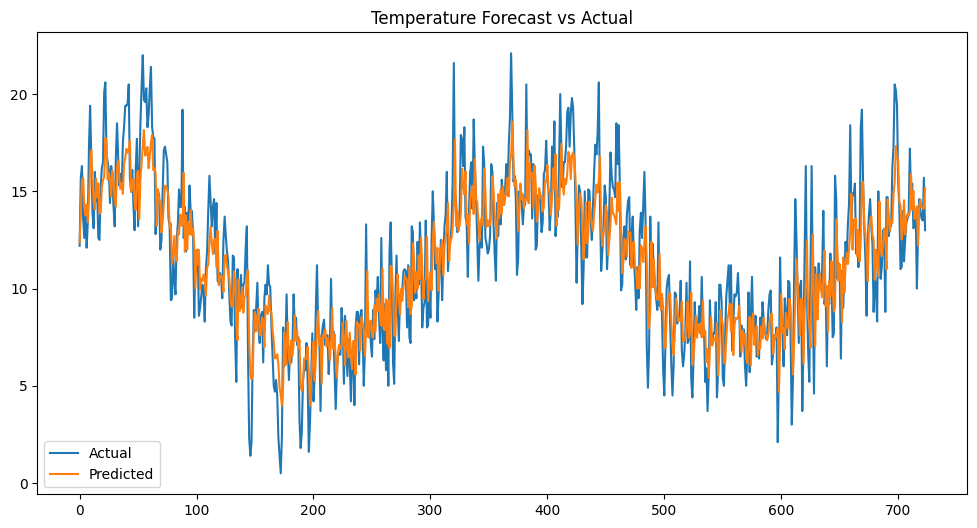

In [19]:
#Visualize predictions vs actual values

plt.figure(figsize=(12, 6))
plt.plot(y_test.values,label = "Actual")
plt.plot(y_pred,label ="Predicted")
plt.title("Temperature Forecast vs Actual")
plt.legend()
plt.show()